# Commission & Slippage Model Comparison

**Docker image**: `ml4t`

Side-by-side comparison of all 6 commission models and 5 slippage models in
`ml4t.backtest.models`. We compute costs for identical trades across varying
sizes, define 4 asset-class cost stacks, and measure the P&L sensitivity and
frequency sensitivity of model choice.

**Learning Objectives**
- Instantiate and compare all 6 commission models and 5 slippage models
- Build asset-class-specific cost configurations (equities, ETFs, futures, crypto)
- Quantify how much model choice affects net Sharpe for different trading styles
- Understand the frequency-cost interaction (daily vs weekly vs monthly)

**Book Reference:** Chapter 18, Section 18.2 (A Cost Taxonomy for Practitioners)

**Prerequisites:** Read [`06_ml4t_execution_demo`](06_ml4t_execution_demo.ipynb)
for the impact API and
[`10_gross_vs_net_performance`](10_gross_vs_net_performance.ipynb) for the
portfolio-level net-performance waterfall.

In [1]:
"""Commission & Slippage Model Comparison."""

import warnings

import plotly.graph_objects as go
import polars as pl
from IPython.display import display
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore")

from ml4t.backtest import (
    BacktestConfig,
    DataFeed,
    Engine,
    ExecutionMode,
    Strategy,
)
from ml4t.backtest.execution.rebalancer import RebalanceConfig, TargetWeightExecutor
from ml4t.backtest.models import (
    CombinedCommission,
    FixedSlippage,
    FuturesCommission,
    FuturesSlippage,
    NoCommission,
    NoSlippage,
    PercentageCommission,
    PercentageSlippage,
    PerShareCommission,
    TieredCommission,
    VolumeShareSlippage,
)

# Side-effect import: configures the default Plotly renderer to embed PNG
# alongside the interactive widget so figures render on GitHub when the
# rendered .ipynb is browsed without a live Plotly runtime.
import utils  # noqa: F401
from data import load_etfs
from utils.reproducibility import set_global_seeds

In [2]:
SEED = 42
N_BARS = 1260  # 5 years daily
INITIAL_CASH = 100_000
ETF_SYMBOLS = ["SPY", "QQQ", "IWM", "XLF", "EEM"]  # liquid, distinct sectors/regions
START_DATE = "2019-01-02"
END_DATE = "2023-12-29"
MOMENTUM_LOOKBACK = 63  # trading days (~quarter) for the rebalance signal

In [3]:
set_global_seeds(SEED)

## 1. Commission Model Taxonomy

The library provides 6 commission models, from zero-cost to futures-specific.
We compute commission for identical trades at varying order sizes and prices
to compare their cost profiles.

In [4]:
commission_models = {
    "NoCommission": NoCommission(),
    "Percentage (10bp)": PercentageCommission(rate=0.001),
    "PerShare ($0.005)": PerShareCommission(per_share=0.005, minimum=1.0),
    "Combined (5bp + $1)": CombinedCommission(percentage=0.0005, fixed=1.0),
    "Tiered": TieredCommission(tiers=[(10_000, 0.001), (50_000, 0.0008), (float("inf"), 0.0005)]),
    "Futures ($2.25/ct)": FuturesCommission(per_block=2.25),
}

# Test scenarios: (quantity, price)
test_sizes = [10, 50, 100, 500, 1000, 5000, 10000]
test_prices = [50.0, 100.0, 500.0]

commission_rows = []
for price in test_prices:
    for name, model in commission_models.items():
        row = {"price": price, "model": name}
        for qty in test_sizes:
            if name == "Futures ($2.25/ct)":
                cost = model.calculate("TEST", qty, price, multiplier=50.0)
            else:
                cost = model.calculate("TEST", qty, price)
            row[f"{qty}sh"] = cost
        commission_rows.append(row)

commission_df = pl.DataFrame(commission_rows)

for price in test_prices:
    print(f"\n--- Price: ${price:.0f} ---")
    display(commission_df.filter(pl.col("price") == price).drop("price"))


--- Price: $50 ---


model,10sh,50sh,100sh,500sh,1000sh,5000sh,10000sh
str,f64,f64,f64,f64,f64,f64,f64
"""NoCommission""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""Percentage (10bp)""",0.5,2.5,5.0,25.0,50.0,250.0,500.0
"""PerShare ($0.005)""",1.0,1.0,1.0,2.5,5.0,25.0,50.0
"""Combined (5bp + $1)""",1.25,2.25,3.5,13.5,26.0,126.0,251.0
"""Tiered""",0.5,2.5,5.0,20.0,40.0,125.0,250.0
"""Futures ($2.25/ct)""",22.5,112.5,225.0,1125.0,2250.0,11250.0,22500.0



--- Price: $100 ---


model,10sh,50sh,100sh,500sh,1000sh,5000sh,10000sh
str,f64,f64,f64,f64,f64,f64,f64
"""NoCommission""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""Percentage (10bp)""",1.0,5.0,10.0,50.0,100.0,500.0,1000.0
"""PerShare ($0.005)""",1.0,1.0,1.0,2.5,5.0,25.0,50.0
"""Combined (5bp + $1)""",1.5,3.5,6.0,26.0,51.0,251.0,501.0
"""Tiered""",1.0,5.0,10.0,40.0,50.0,250.0,500.0
"""Futures ($2.25/ct)""",22.5,112.5,225.0,1125.0,2250.0,11250.0,22500.0



--- Price: $500 ---


model,10sh,50sh,100sh,500sh,1000sh,5000sh,10000sh
str,f64,f64,f64,f64,f64,f64,f64
"""NoCommission""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""Percentage (10bp)""",5.0,25.0,50.0,250.0,500.0,2500.0,5000.0
"""PerShare ($0.005)""",1.0,1.0,1.0,2.5,5.0,25.0,50.0
"""Combined (5bp + $1)""",3.5,13.5,26.0,126.0,251.0,1251.0,2501.0
"""Tiered""",5.0,20.0,40.0,125.0,250.0,1250.0,2500.0
"""Futures ($2.25/ct)""",22.5,112.5,225.0,1125.0,2250.0,11250.0,22500.0


**Finding**: The commission table highlights the fixed-versus-proportional
trade-off. Small tickets are dominated by minimums and fixed fees, while large
tickets quickly become a notional-based cost problem.

**Observations**:
- **NoCommission** is always zero (useful as a reference for isolating other costs)
- **PercentageCommission** scales linearly with trade value --- $50 at 100 shares of
  a $500 stock
- **PerShareCommission** is independent of price --- favors high-priced stocks
  (lower cost as % of value)
- **TieredCommission** drops the per-unit rate as trade value increases (institutional
  volume discounts)
- **CombinedCommission** has a fixed floor plus a percentage --- the fixed component
  dominates for small trades
- **FuturesCommission** is per-contract (per-block), independent of price; the
  multiplier converts to notional value

**Bps-normalized futures example**: a 10-contract ES trade at $4,000 with
multiplier $50 has notional $4,000 x 50 x 10 = $2,000,000. At
`FuturesCommission(per_block=2.25)` the commission is $22.50, which is
$22.50 / $2,000,000 = 0.11 bps of notional. The raw dollar amount looks
small compared to a percentage-fee equity ticket, but per-block commissions
only make sense once normalized against the multiplier-adjusted notional.

## 2. Slippage Model Taxonomy

The 5 slippage models return per-unit price adjustment (except FuturesSlippage
which returns total cost). We compute slippage for varying order sizes
relative to bar volume.

In [5]:
# Standard slippage models (return per-unit price adjustment)
slippage_models = {
    "NoSlippage": NoSlippage(),
    "Fixed ($0.01)": FixedSlippage(amount=0.01),
    "Percentage (10bp)": PercentageSlippage(rate=0.001),
    "VolumeShare (0.1)": VolumeShareSlippage(impact_factor=0.1),
}

# Test at different participation rates
price = 100.0
volume = 1_000_000
participation_rates = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10, 0.20]

print(f"\nSlippage Model Comparison (Price: ${price:.0f}, Volume: {volume:,.0f})")

slippage_rows = []
for name, model in slippage_models.items():
    row = {"model": name}
    for pct in participation_rates:
        qty = volume * pct
        slip = model.calculate("TEST", qty, price, volume)
        row[f"{pct:.1%}"] = slip
    slippage_rows.append(row)

slippage_df = pl.DataFrame(slippage_rows)
display(slippage_df)


Slippage Model Comparison (Price: $100, Volume: 1,000,000)


model,0.1%,0.5%,1.0%,2.0%,5.0%,10.0%,20.0%
str,f64,f64,f64,f64,f64,f64,f64
"""NoSlippage""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""Fixed ($0.01)""",0.01,0.01,0.01,0.01,0.01,0.01,0.01
"""Percentage (10bp)""",0.1,0.1,0.1,0.1,0.1,0.1,0.1
"""VolumeShare (0.1)""",0.01,0.05,0.1,0.2,0.5,1.0,2.0


**Finding**: The slippage table separates fixed execution frictions from
participation-sensitive impact. That distinction matters because only the
latter gets materially worse as order size consumes more of the bar volume.

In [6]:
# FuturesSlippage comparison (returns total cost, not per-unit)
futures_slip = FuturesSlippage(slippage_points=0.25)
print("\nFuturesSlippage (0.25 points, multiplier=50):")
for n_contracts in [1, 2, 5, 10, 25, 50]:
    cost = futures_slip.calculate("ES", n_contracts, 4000.0, multiplier=50.0)
    print(f"  {n_contracts:>3d} contracts: ${cost:.2f} total")


FuturesSlippage (0.25 points, multiplier=50):
    1 contracts: $12.50 total
    2 contracts: $25.00 total
    5 contracts: $62.50 total
   10 contracts: $125.00 total
   25 contracts: $312.50 total
   50 contracts: $625.00 total


**Finding**: Futures slippage behaves differently because the contract
multiplier converts a small tick move into a meaningful dollar cost. That is
why futures transaction costs should be reasoned about in ticks and blocks,
not only in percentage terms.

**Key Difference**: VolumeShareSlippage is the only model that depends on
order size relative to volume --- it captures the market impact of large
orders. At 1% participation, VolumeShareSlippage is comparable to
PercentageSlippage. At 10%+, it becomes substantially more expensive,
reflecting the reality that large orders move prices.

## 3. Asset-Class Cost Configurations

We define representative cost stacks for 4 asset classes and compare
round-trip costs for a standard trade.

In [7]:
asset_class_configs = {
    "US Equities (retail)": {
        "commission": PerShareCommission(per_share=0.005, minimum=1.0),
        "slippage": PercentageSlippage(rate=0.0005),
        "trade_qty": 200,
        "trade_price": 150.0,
        "trade_volume": 2_000_000,
        "description": "IB-style per-share with tight spreads",
    },
    "ETFs (institutional)": {
        "commission": PercentageCommission(rate=0.0003),
        "slippage": VolumeShareSlippage(impact_factor=0.05),
        "trade_qty": 1000,
        "trade_price": 300.0,
        "trade_volume": 10_000_000,
        "description": "Low percentage fee, volume-dependent impact",
    },
    "CME Futures (ES)": {
        "commission": FuturesCommission(per_block=2.25),
        "slippage": FuturesSlippage(slippage_points=0.25),
        "multiplier": 50.0,  # ES contract multiplier ($50 per point)
        "trade_qty": 5,
        "trade_price": 5000.0,
        "trade_volume": 50_000,
        "description": "Per-contract IB rates, 1-tick slippage (point-value $50)",
    },
    "Crypto (spot)": {
        "commission": PercentageCommission(rate=0.001),
        "slippage": PercentageSlippage(rate=0.002),
        "trade_qty": 0.5,
        "trade_price": 40_000.0,
        "trade_volume": 500,
        "description": "Maker/taker + wide spread",
    },
}

### Compute Round-Trip Costs for Each Asset Class

In [8]:
def asset_class_cost_row(asset_class: str, cfg: dict) -> dict:
    """Evaluate one representative trade under its commission and slippage stack.

    For futures, `multiplier` converts contracts to notional dollars and is
    threaded into both the commission and slippage models that accept it.
    `FuturesSlippage.calculate` already returns total dollar cost, so it is
    not multiplied by quantity again; per-unit slippage models (Fixed,
    Percentage, VolumeShare) are multiplied by `abs(qty)` to total them.
    """
    qty = cfg["trade_qty"]
    price = cfg["trade_price"]
    vol = cfg["trade_volume"]
    multiplier = cfg.get("multiplier", 1.0)
    trade_value = abs(qty * price * multiplier)

    commission_model = cfg["commission"]
    # FuturesCommission accepts multiplier; non-futures models ignore it.
    if isinstance(commission_model, FuturesCommission):
        commission = commission_model.calculate("TEST", qty, price, multiplier=multiplier)
    else:
        commission = commission_model.calculate("TEST", qty, price)

    slippage_model = cfg["slippage"]
    if isinstance(slippage_model, FuturesSlippage):
        # Returns total dollar cost already; do not multiply by qty.
        slippage = slippage_model.calculate("TEST", qty, price, vol, multiplier=multiplier)
    else:
        slippage = slippage_model.calculate("TEST", qty, price, vol) * abs(qty)

    total = commission + slippage
    total_bps = total / trade_value * 10_000 if trade_value > 0 else 0.0
    return {
        "asset_class": asset_class,
        "trade_value": trade_value,
        "commission": commission,
        "slippage": slippage,
        "total": total,
        "total_bps": total_bps,
        "description": cfg["description"],
    }

In [9]:
print("\nAsset-Class Cost Stacks")

rows = [asset_class_cost_row(asset_class, cfg) for asset_class, cfg in asset_class_configs.items()]


Asset-Class Cost Stacks


**Interpretation**: The asset-class rows translate abstract model definitions into
realistic trading stacks. Once the same trade is priced under each market’s native
fee logic, the relevant modeling differences become much easier to see.

In [10]:
for row in rows:
    trade_value = row["trade_value"]
    print(f"\n  {row['asset_class']} ({row['description']}):")
    print(f"    Trade value:  ${trade_value:,.0f}")
    print(
        f"    Commission:   ${row['commission']:,.2f} ({row['commission'] / trade_value * 10_000:.1f} bps)"
    )
    print(
        f"    Slippage:     ${row['slippage']:,.2f} ({row['slippage'] / trade_value * 10_000:.1f} bps)"
    )
    print(f"    Total:        ${row['total']:,.2f} ({row['total_bps']:.1f} bps)")


  US Equities (retail) (IB-style per-share with tight spreads):
    Trade value:  $30,000
    Commission:   $1.00 (0.3 bps)
    Slippage:     $15.00 (5.0 bps)
    Total:        $16.00 (5.3 bps)

  ETFs (institutional) (Low percentage fee, volume-dependent impact):
    Trade value:  $300,000
    Commission:   $90.00 (3.0 bps)
    Slippage:     $1.50 (0.1 bps)
    Total:        $91.50 (3.0 bps)

  CME Futures (ES) (Per-contract IB rates, 1-tick slippage (point-value $50)):
    Trade value:  $1,250,000
    Commission:   $11.25 (0.1 bps)
    Slippage:     $62.50 (0.5 bps)
    Total:        $73.75 (0.6 bps)

  Crypto (spot) (Maker/taker + wide spread):
    Trade value:  $20,000
    Commission:   $20.00 (10.0 bps)
    Slippage:     $40.00 (20.0 bps)
    Total:        $60.00 (30.0 bps)


**Finding**: The asset-class table shows why cost modeling must be specific to
the instrument. In some markets commission is negligible and slippage dominates;
in others a fixed fee floor matters more than impact.

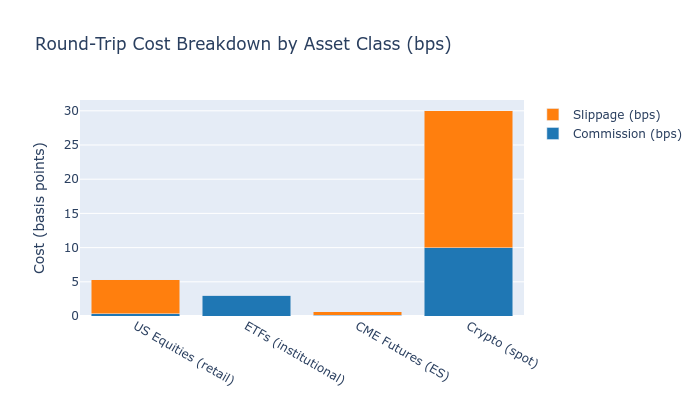

In [11]:
# Visualize cost breakdown by asset class
cost_df = pl.DataFrame(rows)

fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=[r["asset_class"] for r in rows],
        y=[r["commission"] / r["trade_value"] * 10_000 for r in rows],
        name="Commission (bps)",
        marker_color="#1f77b4",
    )
)
fig.add_trace(
    go.Bar(
        x=[r["asset_class"] for r in rows],
        y=[r["slippage"] / r["trade_value"] * 10_000 for r in rows],
        name="Slippage (bps)",
        marker_color="#ff7f0e",
    )
)
fig.update_layout(
    title="Round-Trip Cost Breakdown by Asset Class (bps)",
    yaxis_title="Cost (basis points)",
    barmode="stack",
    height=400,
)
fig.show()

**Finding**: The stacked bars isolate what must be optimized. Where slippage is
most of the stack, better execution matters more than fee negotiation; where
fees dominate, broker or venue choice is the first-order lever.

## 4. P&L Sensitivity: Does Model Choice Matter?

For a liquid ETF momentum strategy with monthly rebalancing, we run the
same strategy using each commission model and compare net Sharpe ratios.
We test whether model choice is second-order at monthly cadence — and check
whether that ordering changes once turnover increases. The price panel is
real daily OHLCV for five liquid ETFs; only the cost model varies between runs.

### Load the Real ETF Price Panel

In [12]:
test_prices_df = (
    load_etfs(symbols=ETF_SYMBOLS, start_date=START_DATE, end_date=END_DATE)
    .select("timestamp", "symbol", "open", "high", "low", "close", "volume")
    .sort("symbol", "timestamp")
)
SYMBOLS = sorted(test_prices_df["symbol"].unique().to_list())
assert set(SYMBOLS) == set(ETF_SYMBOLS), (
    f"loaded universe {SYMBOLS} does not match requested {ETF_SYMBOLS}; "
    "a missing symbol would silently change the experiment"
)
dates = test_prices_df["timestamp"].unique().sort()[:N_BARS]
test_prices_df = test_prices_df.filter(pl.col("timestamp").is_in(dates))
print(
    f"Loaded {test_prices_df.height:,} rows for {len(SYMBOLS)} ETFs "
    f"({dates.min()} .. {dates.max()}, {len(dates)} sessions)"
)

Loaded 6,290 rows for 5 ETFs (2019-01-02 .. 2023-12-29, 1258 sessions)


### Momentum-Based Rebalance Targets

The rebalance signal is a real trailing-momentum rule: at each rebalance date
hold the equal-weighted top three ETFs by their `MOMENTUM_LOOKBACK`-day return.
The signal drives turnover; the cost-model comparison below holds it fixed and
varies only the commission model.

In [13]:
momentum = test_prices_df.with_columns(
    mom=pl.col("close").pct_change(MOMENTUM_LOOKBACK).over("symbol")
)


def make_weight_dict(step: int) -> dict:
    """Equal-weight top-3-by-trailing-momentum targets at the requested cadence."""
    weights = {}
    for ts in dates.gather_every(step):
        ranked = (
            momentum.filter((pl.col("timestamp") == ts) & pl.col("mom").is_not_null())
            .sort("mom", descending=True)
            .head(3)
        )
        if ranked.height == 3:
            weights[ts] = {symbol: 1.0 / 3 for symbol in ranked["symbol"].to_list()}
    return weights

### Monthly Targets for the Base Sensitivity Test

In [14]:
weight_dict = make_weight_dict(21)

## 5. Monthly-Rebalance Sensitivity Harness

We now wire the cost models into a minimal backtest so the comparison moves
from per-trade arithmetic to realized portfolio outcomes.

In [15]:
class SimpleStrategy(Strategy):
    """Rebalance strategy driven by a pre-computed weight dict."""

    def __init__(self, weight_dict):
        self.executor = TargetWeightExecutor(
            config=RebalanceConfig(
                min_trade_value=100.0,
                min_weight_change=0.005,
                allow_fractional=True,
            )
        )
        self._weights = weight_dict

    def on_data(self, timestamp, data, context, broker):
        if timestamp not in self._weights:
            return
        # Restrict targets to symbols actually present in this bar's data; any
        # remaining unexpected exceptions should surface rather than be hidden.
        targets = {a: w for a, w in self._weights[timestamp].items() if a in data}
        if targets:
            self.executor.execute(targets, data, broker)

In [16]:
commission_tests = {
    "NoCommission": NoCommission(),
    "Percentage (10bp)": PercentageCommission(rate=0.001),
    "PerShare ($0.005)": PerShareCommission(per_share=0.005, minimum=1.0),
    "Combined (5bp+$1)": CombinedCommission(percentage=0.0005, fixed=1.0),
    "Tiered (volume)": TieredCommission(
        tiers=[(10_000, 0.001), (50_000, 0.0008), (float("inf"), 0.0005)]
    ),
}

### Run the Monthly-Rebalance Cost Comparison

In [17]:
base_config = BacktestConfig(
    initial_cash=INITIAL_CASH,
    slippage_rate=0.0005,
    execution_mode=ExecutionMode.NEXT_BAR,
)


def run_backtest_variant(weight_dict: dict, commission_model, config: BacktestConfig) -> dict:
    """Execute the simple strategy under one commission model."""
    feed = DataFeed(prices_df=test_prices_df)
    strategy = SimpleStrategy(weight_dict)
    engine = Engine(feed=feed, strategy=strategy, config=config)
    engine.broker.commission_model = commission_model
    result = engine.run()
    return {
        "sharpe": float(result.metrics.get("sharpe", 0.0)),
        "total_return": float(result.equity.total_return),
        "total_commission": float(sum(t.fees for t in result.trades)),
        "n_trades": len(result.trades),
    }

In [18]:
print("\nP&L Sensitivity: Commission Model Impact (Monthly Rebalance)")

pnl_results = {}
for name, comm_model in commission_tests.items():
    pnl_results[name] = run_backtest_variant(weight_dict, comm_model, base_config)


P&L Sensitivity: Commission Model Impact (Monthly Rebalance)


**Finding**: This block isolates model choice with everything else held constant.
The resulting Sharpe spread tells us whether commission specification is a first-order
design choice or a minor implementation detail for this strategy.

In [19]:
for name, metrics in pnl_results.items():
    print(
        f"  {name:<25s}: Sharpe={metrics['sharpe']:.3f}  Return={metrics['total_return']:.2%}  "
        f"Commission=${metrics['total_commission']:,.0f}  Trades={metrics['n_trades']}"
    )

  NoCommission             : Sharpe=0.645  Return=76.85%  Commission=$0  Trades=36
  Percentage (10bp)        : Sharpe=0.623  Return=72.78%  Commission=$3,276  Trades=36
  PerShare ($0.005)        : Sharpe=0.645  Return=76.53%  Commission=$256  Trades=36
  Combined (5bp+$1)        : Sharpe=0.635  Return=74.73%  Commission=$1,743  Trades=36
  Tiered (volume)          : Sharpe=0.630  Return=74.15%  Commission=$2,111  Trades=36


**Finding**: This monthly-rebalance table is the sanity check for overfitting
the cost model. If a slow, liquid strategy changes rank only marginally across
reasonable fee schedules, model detail is a second-order concern.

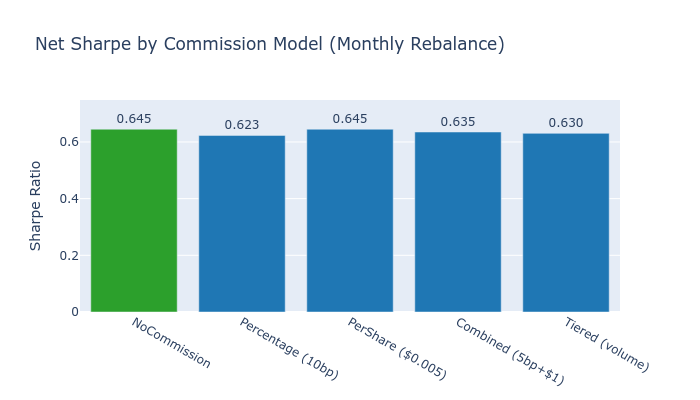


Sharpe range across commission models on this real ETF panel: 0.0220
  (n_bars=1258, n_symbols=5, monthly rebalance)


In [20]:
# Visualize Sharpe comparison
sharpe_vals = [v["sharpe"] for v in pnl_results.values()]
names = list(pnl_results.keys())

fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=names,
        y=sharpe_vals,
        marker_color=["#2ca02c" if s == max(sharpe_vals) else "#1f77b4" for s in sharpe_vals],
        text=[f"{s:.3f}" for s in sharpe_vals],
        textposition="outside",
    )
)
fig.update_layout(
    title="Net Sharpe by Commission Model (Monthly Rebalance)",
    yaxis_title="Sharpe Ratio",
    height=400,
)
fig.show()

sharpe_range = max(sharpe_vals) - min(sharpe_vals)
print(f"\nSharpe range across commission models on this real ETF panel: {sharpe_range:.4f}")
print(f"  (n_bars={len(dates)}, n_symbols={len(SYMBOLS)}, monthly rebalance)")

**Mechanism**: the Sharpe-range scalar compresses the monthly comparison into
one number. Its magnitude is specific to this five-ETF momentum portfolio over
the 2019-2023 window, not a general claim about commission-model sensitivity.
The point of this section is the arithmetic mechanism: percentage and tiered fee
structures accumulate proportionally to traded notional, per-share fees scale
with share count, and the gap between them depends on price level and trade size
rather than on rebalance frequency alone. The relative ordering would shift on a
different universe or trade-size profile, so read the spread as an illustration
of the mechanism rather than a transferable magnitude.

## 6. Frequency Sensitivity

The same strategy at daily, weekly, and monthly cadence. Higher frequency
means more turnover, amplifying cost model differences.

In [21]:
cadences = {"daily": 1, "weekly": 5, "monthly": 21}
cadence_weights = {label: make_weight_dict(days) for label, days in cadences.items()}

In [22]:
test_models = {
    "NoCommission": NoCommission(),
    "Percentage (10bp)": PercentageCommission(rate=0.001),
}

### Run the Frequency-Sensitivity Grid

In [23]:
print("\nFrequency Sensitivity: Cost Impact by Rebalance Cadence")

freq_results = {}
freq_config = BacktestConfig(
    initial_cash=INITIAL_CASH,
    slippage_rate=0.0005,
    execution_mode=ExecutionMode.NEXT_BAR,
)

for cadence_name in cadences:
    for model_name, comm_model in test_models.items():
        key = f"{cadence_name}/{model_name}"
        result = run_backtest_variant(cadence_weights[cadence_name], comm_model, freq_config)
        freq_results[key] = {
            "cadence": cadence_name,
            "model": model_name,
            "sharpe": result["sharpe"],
            "total_commission": result["total_commission"],
            "n_trades": result["n_trades"],
        }


Frequency Sensitivity: Cost Impact by Rebalance Cadence


**Interpretation**: This grid is the important stress test because it changes cadence
while keeping the portfolio construction logic fixed. Any widening in Sharpe gaps is
therefore coming from turnover-amplified costs rather than from a different signal.

In [24]:
for cadence_name in cadences:
    for model_name in test_models:
        metrics = freq_results[f"{cadence_name}/{model_name}"]
        print(
            f"  {cadence_name:>8s} | {model_name:<25s}: "
            f"Sharpe={metrics['sharpe']:.3f}  Commission=${metrics['total_commission']:,.0f}  "
            f"Trades={metrics['n_trades']}"
        )

     daily | NoCommission             : Sharpe=0.485  Commission=$0  Trades=205
     daily | Percentage (10bp)        : Sharpe=0.358  Commission=$16,011  Trades=205
    weekly | NoCommission             : Sharpe=0.594  Commission=$0  Trades=76
    weekly | Percentage (10bp)        : Sharpe=0.547  Commission=$6,490  Trades=76
   monthly | NoCommission             : Sharpe=0.645  Commission=$0  Trades=36
   monthly | Percentage (10bp)        : Sharpe=0.623  Commission=$3,276  Trades=36


**Finding**: The cadence table shows where costs become a design constraint
rather than a reporting adjustment. Daily turnover multiplies commission drag
far faster than monthly turnover, even with the same gross signal.

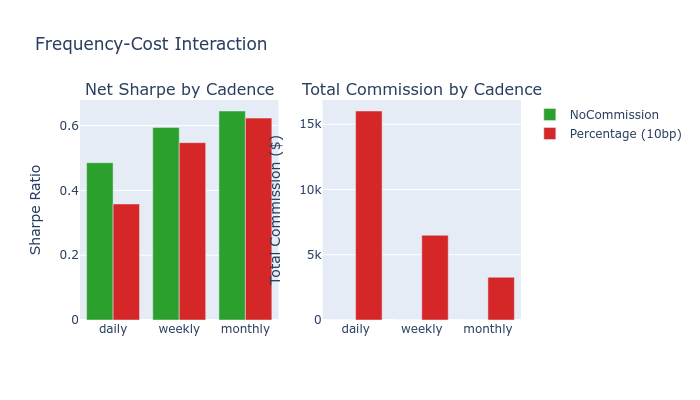

In [25]:
# Visualize frequency sensitivity
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["Net Sharpe by Cadence", "Total Commission by Cadence"],
)

for model_name, color in [("NoCommission", "#2ca02c"), ("Percentage (10bp)", "#d62728")]:
    cadence_labels = []
    sharpes = []
    commissions = []
    for cadence_name in cadences:
        key = f"{cadence_name}/{model_name}"
        if key in freq_results:
            cadence_labels.append(cadence_name)
            sharpes.append(freq_results[key]["sharpe"])
            commissions.append(freq_results[key]["total_commission"])

    fig.add_trace(
        go.Bar(x=cadence_labels, y=sharpes, name=model_name, marker_color=color),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Bar(
            x=cadence_labels,
            y=commissions,
            name=model_name,
            marker_color=color,
            showlegend=False,
        ),
        row=1,
        col=2,
    )

fig.update_yaxes(title_text="Sharpe Ratio", row=1, col=1)
fig.update_yaxes(title_text="Total Commission ($)", row=1, col=2)
fig.update_layout(height=400, title="Frequency-Cost Interaction", barmode="group")
fig.show()

**Finding**: The two-panel chart makes the same point in both units: dollars and
Sharpe. Faster cadence raises the commission bill directly, and the same increase
then appears as a larger deterioration in risk-adjusted performance.

In [26]:
daily_spread = abs(
    freq_results.get("daily/Percentage (10bp)", {}).get("sharpe", 0)
    - freq_results.get("daily/NoCommission", {}).get("sharpe", 0)
)
monthly_spread = abs(
    freq_results.get("monthly/Percentage (10bp)", {}).get("sharpe", 0)
    - freq_results.get("monthly/NoCommission", {}).get("sharpe", 0)
)
amplification = daily_spread / monthly_spread if monthly_spread > 0 else float("inf")
print(f"\nCost drag amplification (daily vs monthly): {amplification:.1f}x")


Cost drag amplification (daily vs monthly): 5.8x


**Finding**: The amplification ratio is the headline number for strategy
design. It tells the reader how much more sensitive a fast strategy is to
small fee changes than a slow strategy using the same portfolio logic.

**Key Insight**: At daily rebalancing, the cost drag is amplified
substantially compared to monthly. The Sharpe gap between
NoCommission and Percentage(10bp) widens as frequency increases,
confirming that for high-frequency strategies, cost model choice
and minimization becomes critical.

For monthly or quarterly strategies on liquid assets, the model
choice is nearly irrelevant --- focus on signal quality. For daily
or intraday strategies, every basis point of cost reduction translates
directly to improved risk-adjusted returns.

## Key Takeaways

This notebook compared all 11 cost models in `ml4t.backtest.models`:

| Model | Type | Key Parameter | Best For |
|-------|------|---------------|----------|
| NoCommission | Commission | - | Baseline reference |
| PercentageCommission | Commission | rate (bps) | Equities, crypto |
| PerShareCommission | Commission | per_share, minimum | US equities (retail) |
| CombinedCommission | Commission | percentage + fixed | Mixed fee structures |
| TieredCommission | Commission | tier thresholds | Institutional volume |
| FuturesCommission | Commission | per_block | Futures contracts |
| NoSlippage | Slippage | - | Baseline reference |
| FixedSlippage | Slippage | amount | Liquid instruments |
| PercentageSlippage | Slippage | rate (bps) | General purpose |
| VolumeShareSlippage | Slippage | impact_factor | Market impact |
| FuturesSlippage | Slippage | slippage_points | Futures contracts |

**Three mechanism observations** (on a real 5-ETF momentum panel, 2019-2023):
1. The arithmetic of commission and slippage models differs by functional
   form (per-share, percentage, tiered, volume-share). The §4 monthly
   sensitivity demonstration produces a non-trivial Sharpe spread across
   models; the magnitude on other deployments depends on price level,
   trade size, and rebalance cadence and should be measured per
   case-study.
2. Total cost drag rises with rebalance frequency in this demonstration
   because more trades cross more bid-ask spreads and incur more impact;
   the §5/§6 cells make the scaling explicit on the real ETF panel.
3. `VolumeShareSlippage` is the only slippage model in the chapter that
   captures market-impact's non-linear scaling with order size — the
   `FixedSlippage` and `PercentageSlippage` models charge a constant
   rate per trade regardless of size.

> **Book Reference**: Section 18.2 (cost taxonomy), Section 18.3
> (market impact models), Section 18.4 (frequency-cost interaction).

**Next**: See [`10_gross_vs_net_performance`](10_gross_vs_net_performance.ipynb) for portfolio-level cost drag
and [`06_ml4t_execution_demo`](06_ml4t_execution_demo.ipynb) for the execution-facing API.